In [6]:
'''
Alternative implementation of the poisson distributed autapse delay more in line with gamma distribution scheme

autapse firing is less than 1:1 with the neuron's spiking.

'''


import sys
sys.path.append("../")

from brian2 import *
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *

from functions import *

In [7]:

"""- - - - MAIN SIMULATION - - - - """

T = 2000 # ms
N_trials = 100
N_spikes = 100
spike_delay = 4*ms
counts = np.zeros(N_trials)

spike_delays = []

for i in tqdm(range(N_trials)):
    # 1. Setup Input (Presynaptic Neuron)
    # Let's say it fires at 20Hz
    #P = PoissonGroup(1, 20*Hz)
    idx = np.zeros(N_spikes)
    spike_times = np.linspace(10, 3*T/4, N_spikes)*ms
    ms_per_spike = (T/2 - 10)/N_spikes
    firing_frequency = 1000/ms_per_spike
    #print(f"FF: {firing_frequency}")
    P = SpikeGeneratorGroup(1, idx, spike_times)


    # 2. The Poisson Generator Group
    # 'rho' acts as the instantaneous firing rate
    tau_decay = spike_delay     # How long the "influence" of a pre-spike lasts
    gain = 1/(spike_delay)      # How much each pre-spike adds to the output rate

    PoissonGen = NeuronGroup(1, 
        '''
        rate = 1/tau_decay : Hz  # Rate decays over time
        is_active : 1
        ''',
        threshold = 'is_active > 0 and rand() < rate * dt', 
        reset = 'is_active -= 1',
        method = 'euler')
    

    # 3. Connect Pre-synapse to the Generator
    # Each spike from P increases the firing rate of PoissonGen
    S_in = Synapses(P, PoissonGen, on_pre='is_active += 1')
    S_in.connect()

    # 4. Connect Generator to Post-synaptic Target
    Post = NeuronGroup(1, 'dv/dt = -v/(10*ms) : 1', threshold='v>1', reset='v=0')
    S_out = Synapses(PoissonGen, Post, on_pre='v_post += 0.3')
    S_out.connect()


    # Monitors
    mon_p = SpikeMonitor(P)
    mon_gen = SpikeMonitor(PoissonGen, record = True)
    mon_rate = StateMonitor(PoissonGen, 'is_active', record=True)
    mon_post = StateMonitor(Post, 'v', record = True)
    spikemon_post = SpikeMonitor(Post, record = True)

    
    run(T*ms)


    spk_trn = mon_gen.spike_trains()[0]
    counts[i] = len(spk_trn)


    for spike in spk_trn:
        #print(spike)
        delay = spike - spike_times[spike_times < spike][-1]    #last spike before the poisson spike
        #print(delay)
        spike_delays.append(delay*1000)


100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


[0.01       0.02505051 0.04010101 0.05515152 0.07020202 0.08525253
 0.10030303 0.11535354 0.13040404 0.14545455 0.16050505 0.17555556
 0.19060606 0.20565657 0.22070707 0.23575758 0.25080808 0.26585859
 0.28090909 0.2959596  0.3110101  0.32606061 0.34111111 0.35616162
 0.37121212 0.38626263 0.40131313 0.41636364 0.43141414 0.44646465
 0.46151515 0.47656566 0.49161616 0.50666667 0.52171717 0.53676768
 0.55181818 0.56686869 0.58191919 0.5969697  0.6120202  0.62707071
 0.64212121 0.65717172 0.67222222 0.68727273 0.70232323 0.71737374
 0.73242424 0.74747475 0.76252525 0.77757576 0.79262626 0.80767677
 0.82272727 0.83777778 0.85282828 0.86787879 0.88292929 0.8979798
 0.9130303  0.92808081 0.94313131 0.95818182 0.97323232 0.98828283
 1.00333333 1.01838384 1.03343434 1.04848485 1.06353535 1.07858586
 1.09363636 1.10868687 1.12373737 1.13878788 1.15383838 1.16888889
 1.18393939 1.1989899  1.2140404  1.22909091 1.24414141 1.25919192
 1.27424242 1.28929293 1.30434343 1.31939394 1.33444444 1.34949

Text(0, 0.5, 'v [mV]')

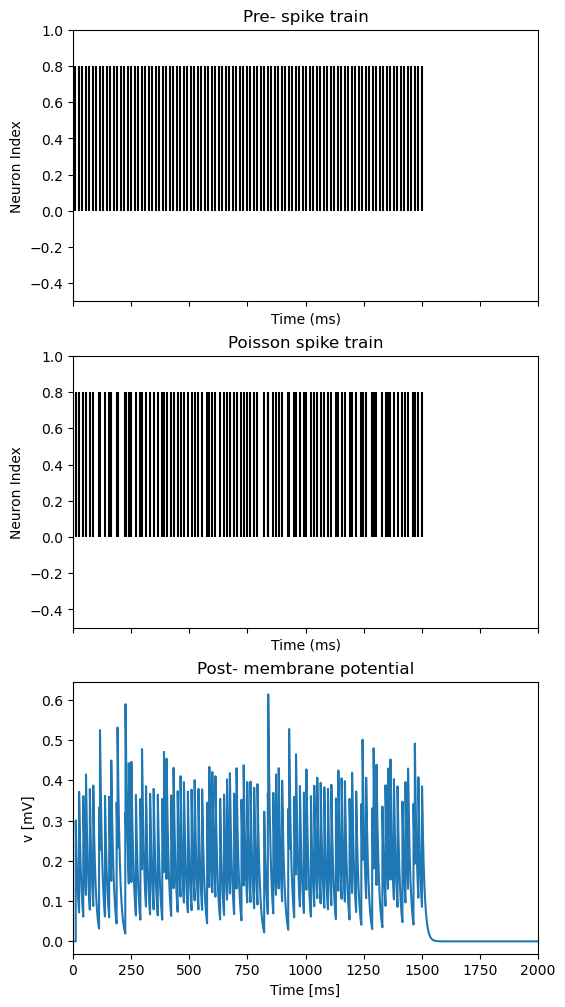

In [8]:
fig, ax = plt.subplots(3, 1, figsize = (6, 12), sharex = True)

print(spike_times)

plot_raster(np.array([spike_times/ms]), T, ax = ax[0])
ax[0].set_title("Pre- spike train")

plot_raster(np.array([spk_trn/ms]), T, ax = ax[1])
ax[1].set_title("Poisson spike train")

ax[2].plot(mon_post.t/ms, mon_post.v[0])
ax[2].set_title("Post- membrane potential")
ax[2].set_xlabel("Time [ms]")
ax[2].set_ylabel("v [mV]")

DEFAULT DT: 0.1 ms^2
Mean: 100.0
STD: 0.0
Mean Ratio = 1.0
STD Ratio = 0.0


Text(0.5, 0, 'Time (ms)')

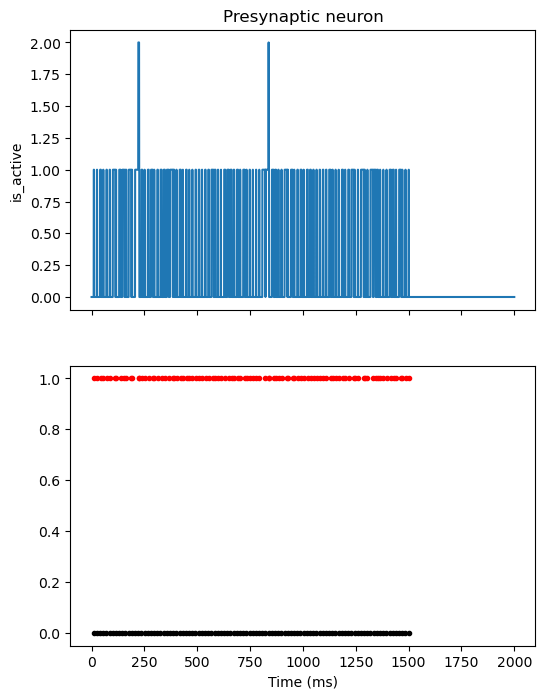

In [9]:
# Visualization of the frequency transformation
print(f"DEFAULT DT: {defaultclock.dt*ms}")


avg_poiss = np.mean(counts)
std_poiss = np.std(counts)
print(f"Mean: {avg_poiss}")
print(f"STD: {std_poiss}")
print(f"Mean Ratio = {avg_poiss/N_spikes}")
print(f"STD Ratio = {std_poiss/N_spikes}")

fig, ax = plt.subplots(2, 1, figsize = (6, 8), sharex = True)

ax[0].plot(mon_rate.t/ms, mon_rate.is_active[0]/Hz)
ax[0].set_title('Presynaptic neuron')
ax[0].set_ylabel('is_active')


ax[1].plot(mon_p.t/ms, mon_p.i, '.k', label='Pre-synaptic')
ax[1].plot(mon_gen.t/ms, mon_gen.i + 1, '.r', label='Poisson Gen')
ax[1].set_xlabel('Time (ms)')


Text(0, 0.5, 'Time delay of synapse [ms]')

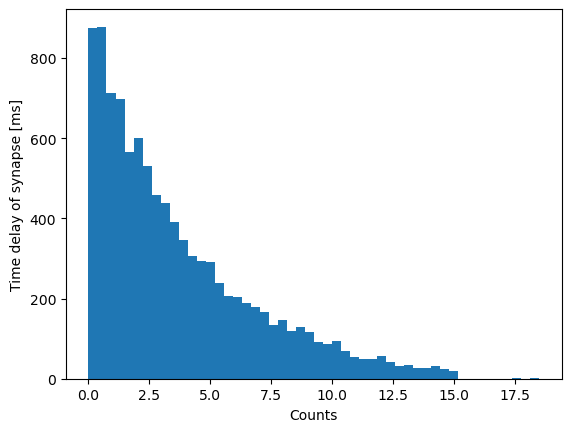

In [10]:

plt.hist(spike_delays, bins = 50)
plt.xlabel("Counts")
plt.ylabel("Time delay of synapse [ms]")